In [ ]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_ta as ta
import optuna
import math


In [146]:
def load_candles(base,quote,timeframe):
    data = pd.read_json(f'/media/mu6mula/Data/Crypto-Data-Feed/freq-user-data/data/binance/{base}_{quote}-{timeframe}.json')
    data.columns = ['timestamp', 'open', 'high', 'low', 'close', 'volume']
    data['timestamp'] = pd.to_datetime(data['timestamp'], unit='ms')
    data.set_index('timestamp', inplace=True)
    return data

In [170]:

# Load the data
data = load_candles('ALGO','USDT','8h')
data = data['2021-11-01':].copy()

# Define transaction costs and slippage
transaction_cost = 0.001  # 0.1% transaction cost per trade
slippage = 0.001  # 0.1% slippage per trade



# Define the fitness function
# def calculate_indicators(data, params):
    
def calculate_metrics(data, params):
    ema_fast_len, ema_slow_len, ema_margin_atr_len, ema_margin_atr_mult = params
    
    # Ensure that parameters are valid
    ema_fast_len = max(1, int(ema_fast_len))
    ema_slow_len = max(1, int(ema_slow_len))
    ema_margin_atr_len = max(1, int(ema_margin_atr_len))
    
    # Calculate indicators using pandas_ta
    data['ema_fast'] = ta.sma(data['close'], length=ema_fast_len)
    data['ema_slow'] = ta.ema(data['close'], length=ema_slow_len)
    data['atr'] = ta.atr(data['high'], data['low'], data['close'], length=ema_margin_atr_len)
    data['ema_diff'] = data['ema_fast'] - data['ema_slow']
    
    # Generate entry signals 
    data['bull'] = (data['ema_diff'] > (ema_margin_atr_mult * data['atr'])) & ((data['close'] > data['ema_fast']))
    
    # Generate exit signals
    data['exit'] =  (data['close'] < data['ema_fast'])
    # data['exit'] = (data['close'] > data['ema_slow']) & (data['close'] < data['ema_fast'])
    
    # Initialize the 'position' column
    data['position'] = 0
    
    # Set the 'position' column based on the signals
    data.loc[data['bull'], 'position'] = 1
    
    # Exit position when exit signal is True
    data.loc[data['exit'], 'position'] = 0
    
    # Forward fill the position to maintain the position until a signal changes
    # data['position'] = data['position'].replace(to_replace=0, method='ffill')
    
    # Calculate number of trades
    data['trade'] = data['position'].diff().abs()
    number_of_trades = data['trade'].sum() / 2  # Each trade consists of an entry and an exit
    
    # Calculate strategy returns
    data['strategy_returns'] = data['position'].shift(1) * data['close'].pct_change()
    
    
    # Apply transaction costs and slippage only on trades
    data['strategy_returns'] -= data['trade'] * (transaction_cost + slippage)

    data['cumulative_returns'] = (1 + data['strategy_returns']).cumprod()
    
    # Calculate performance metrics
    total_return = data['cumulative_returns'].iloc[-1] - 1
    annualized_return = data['strategy_returns'].mean() * 365 * 24 / 8  # Assuming 8-hour bars
    annualized_volatility = data['strategy_returns'].std() * np.sqrt(365 * 24 / 8)
    sharpe_ratio = annualized_return / annualized_volatility
    

    # Calculate trade returns
    data['trade_returns'] = data['strategy_returns'] * data['trade'].shift(-1)

    # Calculate winning trades and losing trades
    winning_trades = data['trade_returns'][data['trade_returns'] > 0]
    losing_trades = data['trade_returns'][data['trade_returns'] <= 0]

    # Calculate win ratio
    if number_of_trades > 0:
        win_ratio = len(winning_trades) / number_of_trades
    else:
        win_ratio = np.nan

    # Calculate average win and average loss
    average_win = winning_trades.mean() if len(winning_trades) > 0 else np.nan
    average_loss = losing_trades.mean() if len(losing_trades) > 0 else np.nan

    
    return sharpe_ratio,total_return,annualized_return,number_of_trades,win_ratio,average_win,average_loss

# Define the objective function for Optuna
def objective(trial):
    ema_fast_len = trial.suggest_int('ema_fast_len', 7, 50)
    ema_slow_len = trial.suggest_int('ema_slow_len', 50, 100)
    ema_margin_atr_len = trial.suggest_int('ema_margin_atr_len', 7, 50)
    ema_margin_atr_mult = trial.suggest_uniform('ema_margin_atr_mult', 0.1, 5)
    
    params = (ema_fast_len, ema_slow_len, ema_margin_atr_len, ema_margin_atr_mult)
    sharpe_ratio,total_return,annualized_return,number_of_trades,win_ratio,average_win,average_loss = calculate_metrics(data, params)
    
    return sharpe_ratio #/ math.cos(number_of_trades)

# Run the optimization
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

# Get the best parameters
best_params = study.best_params
print(f"Best Parameters: {best_params}")

def print_performance(data,best_params):
    # ema_fast_len, ema_slow_len, ema_margin_atr_len, ema_margin_atr_mult
    sharpe_ratio,total_return,annualized_return,number_of_trades,win_ratio,average_win,average_loss = calculate_metrics(
        data, 
        [best_params['ema_fast_len'],best_params['ema_slow_len'],
        best_params['ema_margin_atr_len'],best_params['ema_margin_atr_mult']]
        )


    # Plot the results with the best parameters
    plt.figure(figsize=(14, 3))
    plt.plot(data.index, data['close'], label='Close Price',lw=0.5)
    plt.plot(data.index, data['ema_fast'], label='EMA Fast', color='blue',lw=0.5)
    plt.plot(data.index, data['ema_slow'], label='SMA Slow', color='red',lw=0.5)
    plt.fill_between(data.index, data['ema_fast'], data['ema_slow'], where=data['bull'], color='green', alpha=0.3, label='Bullish')
    plt.legend(loc='best')
    plt.title('{BASE}/{QUOTE} Price and EMAs with Optimized Strategy Signals')


    ax2 = plt.twinx()
    ax2.plot(data.index, data['cumulative_returns'], label='Cumulative Returns', color='purple')

    plt.show()

# Plot cumulative returns with the best parameters
# plt.figure(figsize=(14, 3))
# plt.plot(data.index, data['cumulative_returns'], label='Cumulative Returns', color='purple')
# plt.legend(loc='best')
# plt.title('Cumulative Returns of the Optimized Strategy')
# plt.show()

    # Print final cumulative return with the best parameters
    print(f"Final Cumulative Return with Optimized Parameters: {data['cumulative_returns'].iloc[-1]:.2f}")

    # Print performance metrics
    print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
    print(f"Total Return: {total_return:.2f}")
    print(f"Annualized Return: {annualized_return:.2f}")
    print(f"Number of Trades: {number_of_trades:.0f}")
    print(f"Win Ratio: {win_ratio:.2f}")
    print(f"Average Win: {average_win:.4f}")
    print(f"Average Loss: {average_loss:.4f}")



[I 2024-08-03 21:15:59,535] A new study created in memory with name: no-name-ce02fca2-acf3-4220-b862-a845961732ee
[W 2024-08-03 21:15:59,541] Trial 0 failed with parameters: {'ema_fast_len': 17, 'ema_slow_len': 63, 'ema_margin_atr_len': 36, 'ema_margin_atr_mult': 4.751767321235735} because of the following error: The value nan is not acceptable.
[W 2024-08-03 21:15:59,542] Trial 0 failed with value nan.
[I 2024-08-03 21:15:59,545] Trial 1 finished with value: 0.22953309885867673 and parameters: {'ema_fast_len': 36, 'ema_slow_len': 58, 'ema_margin_atr_len': 30, 'ema_margin_atr_mult': 0.10966984141777186}. Best is trial 1 with value: 0.22953309885867673.
[I 2024-08-03 21:15:59,549] Trial 2 finished with value: 0.4980179647296823 and parameters: {'ema_fast_len': 36, 'ema_slow_len': 90, 'ema_margin_atr_len': 46, 'ema_margin_atr_mult': 2.4984516828071164}. Best is trial 2 with value: 0.4980179647296823.
[I 2024-08-03 21:15:59,553] Trial 3 finished with value: 0.1810059878417699 and paramete

Best Parameters: {'ema_fast_len': 43, 'ema_slow_len': 69, 'ema_margin_atr_len': 43, 'ema_margin_atr_mult': 1.6949624865306496}


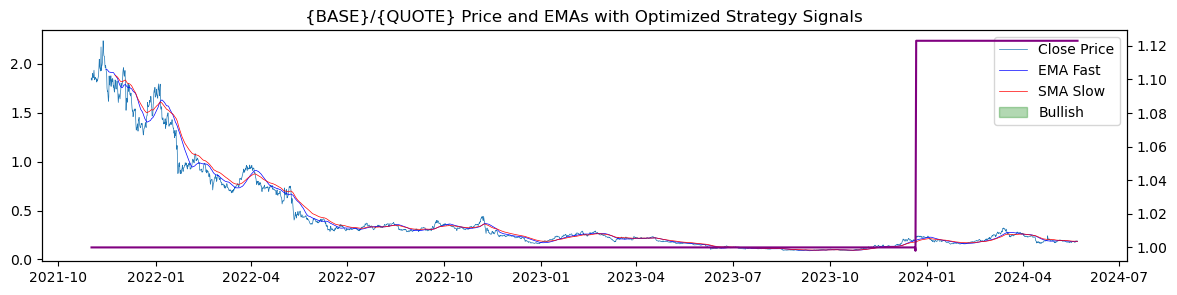

Final Cumulative Return with Optimized Parameters: 1.12
Sharpe Ratio: 0.87
Total Return: 0.12
Annualized Return: 0.05
Number of Trades: 1
Win Ratio: 1.00
Average Win: 0.0589
Average Loss: 0.0000
{'ema_fast_len': 43, 'ema_slow_len': 69, 'ema_margin_atr_len': 43, 'ema_margin_atr_mult': 1.6949624865306496}


In [175]:
print_performance(data,best_params)
print(best_params)

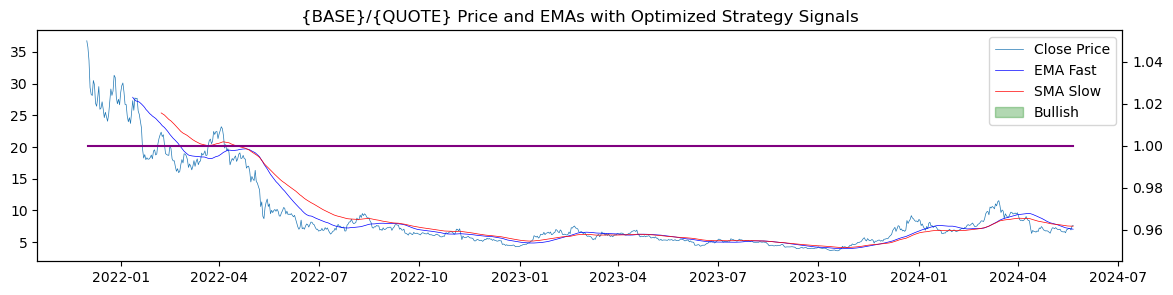

Final Cumulative Return with Optimized Parameters: 1.00
Sharpe Ratio: nan
Total Return: 0.00
Annualized Return: 0.00
Number of Trades: 0
Win Ratio: nan
Average Win: nan
Average Loss: 0.0000


In [179]:
data2 = load_candles('DOT','USDT','1d')
data2 = data2['2021-12-01':]
print_performance(data2,best_params)
